# Fashion Product Images Dataset - Étape 1

Installation des dépendances et téléchargement du dataset

## 1. Installation des dépendances

In [1]:
!pip install kaggle pandas numpy pillow matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import os
import zipfile
from pathlib import Path



## 2. Configuration de Kaggle

**Important :**
1. Allez sur https://www.kaggle.com/settings
2. Cliquez sur "Create New API Token"
3. Téléchargez le fichier kaggle.json
4. Uploadez-le ci-dessous

In [3]:
import os
import json

print("🔑 Configuration Kaggle")
print("-" * 40)

kaggle_key = input("Entrez votre Kaggle API key: ")

# Créer le dossier .kaggle
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

# Créer le fichier kaggle.json (avec un username vide)
kaggle_json = {
    "username": "",
    "key": kaggle_key
}

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_json, f)

# Changer les permissions
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

print("\n✅ Token Kaggle configuré avec succès")

🔑 Configuration Kaggle
----------------------------------------
Entrez votre Kaggle API key: KGAT_188ccaa6ef14650bfa986c232e050a60

✅ Token Kaggle configuré avec succès


## 3. Téléchargement du dataset



In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")

print("Path to dataset files:", path)

100%|██████████| 23.1G/23.1G [04:28<00:00, 92.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-dataset/versions/1


In [5]:
!ls -la {path}

total 12
drwxr-xr-x 3 root root 4096 Mar 16 20:16 .
drwxr-xr-x 3 root root 4096 Mar 16 20:16 ..
drwxr-xr-x 5 root root 4096 Mar 16 20:22 fashion-dataset


## 4. Extraction du dataset

In [6]:
import pandas as pd

# Charger le fichier principal
styles_df = pd.read_csv(f"{path}/fashion-dataset/styles.csv", on_bad_lines='skip')

print(f"✅ Dataset chargé : {len(styles_df)} produits")
print(f"Colonnes : {list(styles_df.columns)}")
styles_df.head()

✅ Dataset chargé : 44424 produits
Colonnes : ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [7]:
import pandas as pd

# Charger le fichier principal
styles_df = pd.read_csv(f"{path}/fashion-dataset/images.csv", on_bad_lines='skip')

print(f"✅ Dataset chargé : {len(styles_df)} produits")
print(f"Colonnes : {list(styles_df.columns)}")
styles_df.head()

✅ Dataset chargé : 44446 produits
Colonnes : ['filename', 'link']


,filename,link
0,15970.jpg,http://assets.myntassets.com/v1/images/style/p...
1,39386.jpg,http://assets.myntassets.com/v1/images/style/p...
2,59263.jpg,http://assets.myntassets.com/v1/images/style/p...
3,21379.jpg,http://assets.myntassets.com/v1/images/style/p...
4,53759.jpg,http://assets.myntassets.com/v1/images/style/p...


In [8]:
DATASET_PATH = path + "/fashion-dataset"

In [9]:
# Charger le fichier COMPLET pour voir toutes les catégories
# On ignore les lignes mal formatées
styles_full = pd.read_csv(
    f"{DATASET_PATH}/styles.csv",
    on_bad_lines='skip'  # Sauter les lignes problématiques
)

print(f"📊 Total produits : {len(styles_full)}")
print(f"\n🏷️ Catégories disponibles (masterCategory) :")
category_counts = styles_full['articleType'].value_counts()
print(category_counts)
print(f"\n✅ Nombre de catégories : {len(category_counts)}")

📊 Total produits : 44424

🏷️ Catégories disponibles (masterCategory) :
articleType
Tshirts                7067
Shirts                 3217
Casual Shoes           2845
Watches                2542
Sports Shoes           2036
                       ... 
Cushion Covers            1
Mens Grooming Kit         1
Body Wash and Scrub       1
Suits                     1
Ipad                      1
Name: count, Length: 143, dtype: int64

✅ Nombre de catégories : 143


In [10]:
# Charger les 2 CSV
styles_df = pd.read_csv(f"{DATASET_PATH}/styles.csv", on_bad_lines='skip')
images_df = pd.read_csv(f"{DATASET_PATH}/images.csv")

print(f"✅ styles.csv : {len(styles_df)} produits")
print(f"✅ images.csv : {len(images_df)} images")

# Fusionner sur l'ID
# images_df a 'filename' = "15970.jpg"
# styles_df a 'id' = 15970
images_df['id'] = images_df['filename'].str.replace('.jpg', '').astype(int)

merged_df = pd.merge(styles_df, images_df, on='id', how='inner')

print(f"\n🔗 Fusion : {len(merged_df)} produits avec image")
print(f"\n📋 Colonnes après fusion : {list(merged_df.columns)}")
merged_df.head(3)

✅ styles.csv : 44424 produits
✅ images.csv : 44446 images

🔗 Fusion : 44424 produits avec image

📋 Colonnes après fusion : ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'filename', 'link']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,filename,link
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,15970.jpg,http://assets.myntassets.com/v1/images/style/p...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,39386.jpg,http://assets.myntassets.com/v1/images/style/p...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,59263.jpg,http://assets.myntassets.com/v1/images/style/p...


In [11]:
# Sélectionner 8 catégories principales (subCategory)
top_8_categories = category_counts.head(8).index.tolist()

print(f"🎯 8 catégories sélectionnées :")
for i, cat in enumerate(top_8_categories, 1):
    print(f"  {i}. {cat}: {category_counts[cat]} produits")

# Échantillonner 50 produits par catégorie
sampled_dfs = []
for category in top_8_categories:
    cat_df = merged_df[merged_df['subCategory'] == category]
    sample = cat_df.sample(n=min(50, len(cat_df)), random_state=42)
    sampled_dfs.append(sample)

final_df = pd.concat(sampled_dfs, ignore_index=True)

print(f"\n✅ Échantillon final : {len(final_df)} produits")
print(f"   Répartition par sous-catégorie (articleType) :")
print(final_df['articleType'].value_counts().sort_index())

🎯 8 catégories sélectionnées :
  1. Tshirts: 7067 produits
  2. Shirts: 3217 produits
  3. Casual Shoes: 2845 produits
  4. Watches: 2542 produits
  5. Sports Shoes: 2036 produits
  6. Kurtas: 1844 produits
  7. Tops: 1762 produits
  8. Handbags: 1759 produits

✅ Échantillon final : 50 produits
   Répartition par sous-catégorie (articleType) :
articleType
Watches    50
Name: count, dtype: int64


In [12]:
# Utiliser merged_df pour les catégories (pas styles_full)
merged_category_counts = merged_df['subCategory'].value_counts()

# Sélectionner 8 catégories principales
top_8_categories = merged_category_counts.head(8).index.tolist()

print(f"🎯 8 catégories sélectionnées :")
for i, cat in enumerate(top_8_categories, 1):
    print(f"  {i}. {cat}: {merged_category_counts[cat]} produits")

# Échantillonner 50 produits par catégorie
sampled_dfs = []
for category in top_8_categories:
    cat_df = merged_df[merged_df['subCategory'] == category]
    sample = cat_df.sample(n=min(50, len(cat_df)), random_state=42)
    sampled_dfs.append(sample)
    print(f"   ✓ {category}: {len(sample)} produits")

final_df = pd.concat(sampled_dfs, ignore_index=True)

print(f"\n✅ Échantillon final : {len(final_df)} produits")
print(f"   Répartition par catégorie :")
print(final_df['subCategory'].value_counts())

🎯 8 catégories sélectionnées :
  1. Topwear: 15402 produits
  2. Shoes: 7343 produits
  3. Bags: 3055 produits
  4. Bottomwear: 2694 produits
  5. Watches: 2542 produits
  6. Innerwear: 1808 produits
  7. Jewellery: 1079 produits
  8. Eyewear: 1073 produits
   ✓ Topwear: 50 produits
   ✓ Shoes: 50 produits
   ✓ Bags: 50 produits
   ✓ Bottomwear: 50 produits
   ✓ Watches: 50 produits
   ✓ Innerwear: 50 produits
   ✓ Jewellery: 50 produits
   ✓ Eyewear: 50 produits

✅ Échantillon final : 400 produits
   Répartition par catégorie :
subCategory
Topwear       50
Shoes         50
Bags          50
Bottomwear    50
Watches       50
Innerwear     50
Jewellery     50
Eyewear       50
Name: count, dtype: int64


In [13]:
# Créer le CSV partiel avec les champs qu'on a
products_partial = pd.DataFrame({
    'id': final_df['id'],
    'nom': final_df['productDisplayName'],
    'categorie': final_df['subCategory'],      # subCategory = catégorie principale
    'sous_categorie': final_df['articleType'],  # articleType = sous-catégorie
    'couleur': final_df['baseColour'],
    'image_path': final_df['filename'].apply(lambda x: f"images/{x}")
})

# Afficher un aperçu
print("📋 Aperçu du dataset partiel :")
print(products_partial.head(10))

print(f"\n✅ Dimensions : {products_partial.shape}")
print(f"   Colonnes : {list(products_partial.columns)}")
print(f"\n📊 Distribution des catégories :")
print(products_partial['categorie'].value_counts())

📋 Aperçu du dataset partiel :
      id                                               nom categorie  \
0  15832                  Visudh Pink Printed Ethnic Kurta   Topwear   
1  33968                          Femella Women Gold Shirt   Topwear   
2   3314             Guerrilla Men's Warrior Brown T-shirt   Topwear   
3  11767                      Lee Men Printed Grey Tshirts   Topwear   
4   8725       Indigo Nation Men Checks Shirt Black Shirts   Topwear   
5  24532                Mother Earth Women Off white Kurta   Topwear   
6  24756                         Spykar Men Green Sweaters   Topwear   
7  38808                    Music Men Blue Printed T-shirt   Topwear   
8   8356  Doodle Boy's End Is Just Begining Black Kidswear   Topwear   
9  31279           Puma Men Bonn Graphic Navy Blue T-shirt   Topwear   

  sous_categorie    couleur        image_path  
0         Kurtas       Pink  images/15832.jpg  
1         Shirts       Gold  images/33968.jpg  
2        Tshirts      Brown   ima

In [14]:
# Sauvegarder le CSV partiel
output_path = "products_partial.csv"
products_partial.to_csv(output_path, index=False)

print(f"💾 CSV partiel sauvegardé : {output_path}")
print(f"   Taille : {products_partial.shape[0]} produits × {products_partial.shape[1]} champs")

# Résumé
print(f"\n📊 Résumé :")
print(f"   ✅ 8 catégories (subCategory) : {', '.join(top_8_categories[:3])}...")
print(f"   ✅ ~50 produits par catégorie")
print(f"   ✅ Champs remplis : id, nom, categorie (subCategory), sous_categorie (articleType), couleur, image_path")
print(f"\n⏳ Champs à générer : description, prix, matiere")

💾 CSV partiel sauvegardé : products_partial.csv
   Taille : 400 produits × 6 champs

📊 Résumé :
   ✅ 8 catégories (subCategory) : Topwear, Shoes, Bags...
   ✅ ~50 produits par catégorie
   ✅ Champs remplis : id, nom, categorie (subCategory), sous_categorie (articleType), couleur, image_path

⏳ Champs à générer : description, prix, matiere


In [15]:
import shutil
import os

# Define paths
SUBSET_DIR = 'subset_fashion_dataset'
SUBSET_IMAGES_DIR = os.path.join(SUBSET_DIR, 'images')

# Create directories
os.makedirs(SUBSET_IMAGES_DIR, exist_ok=True)

# Copy images from the original dataset to the subset folder
print("Copying images...")
count = 0
for idx, row in products_partial.iterrows():
    image_name = row['image_path'].split('/')[-1]
    source = os.path.join(DATASET_PATH, 'images', image_name)
    destination = os.path.join(SUBSET_IMAGES_DIR, image_name)

    if os.path.exists(source):
        shutil.copy(source, destination)
        count += 1

# Save the CSV into the new folder
products_partial.to_csv(os.path.join(SUBSET_DIR, 'metadata.csv'), index=False)

print(f"✅ Done! {count} images copied to {SUBSET_IMAGES_DIR}")
print(f"✅ Metadata saved to {SUBSET_DIR}/metadata.csv")

Copying images...
✅ Done! 400 images copied to subset_fashion_dataset/images
✅ Metadata saved to subset_fashion_dataset/metadata.csv


/tmp/ipykernel_315/134833340.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='categorie', data=products_partial, order=products_partial['categorie'].value_counts().index, palette='viridis')


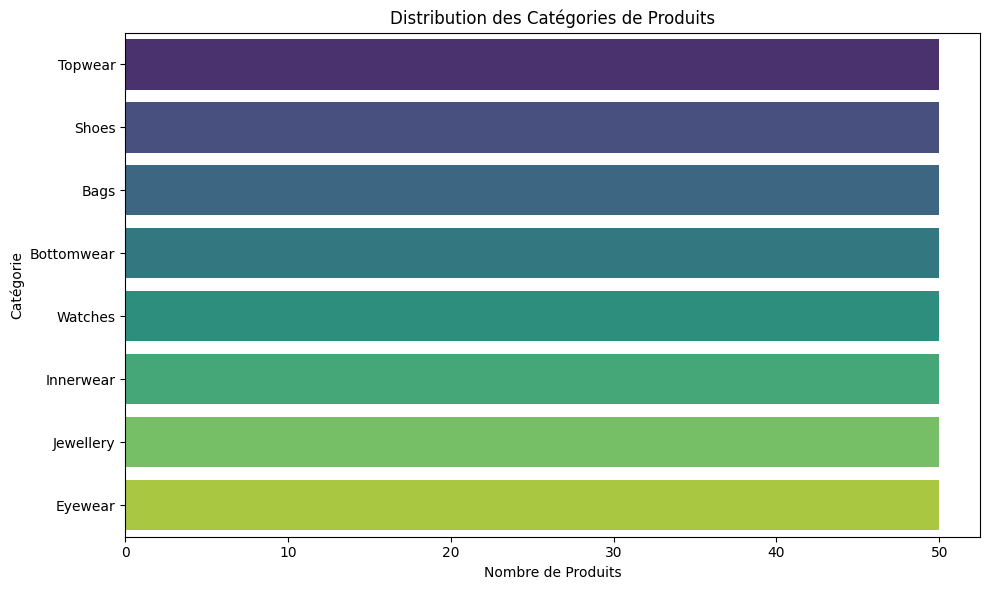

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(y='categorie', data=products_partial, order=products_partial['categorie'].value_counts().index, palette='viridis')
plt.title('Distribution des Catégories de Produits')
plt.xlabel('Nombre de Produits')
plt.ylabel('Catégorie')
plt.tight_layout()
plt.show()

In [17]:
# Verify the content
nb_images = len(os.listdir(SUBSET_IMAGES_DIR))
print(f"Number of images in subset: {nb_images}")

# Show first few rows of the new metadata file
subset_df = pd.read_csv(f'{SUBSET_DIR}/metadata.csv')
display(subset_df.head())

Number of images in subset: 400


,id,nom,categorie,sous_categorie,couleur,image_path
0,15832,Visudh Pink Printed Ethnic Kurta,Topwear,Kurtas,Pink,images/15832.jpg
1,33968,Femella Women Gold Shirt,Topwear,Shirts,Gold,images/33968.jpg
2,3314,Guerrilla Men's Warrior Brown T-shirt,Topwear,Tshirts,Brown,images/3314.jpg
3,11767,Lee Men Printed Grey Tshirts,Topwear,Tshirts,Grey,images/11767.jpg
4,8725,Indigo Nation Men Checks Shirt Black Shirts,Topwear,Shirts,Black,images/8725.jpg


In [18]:
from google.colab import drive
import shutil
import os

# Mount Google Drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Define source and destination
source_dir = 'subset_fashion_dataset'
destination_dir = '/content/drive/My Drive/subset_fashion_dataset'

# Copy the directory to Drive
if os.path.exists(destination_dir):
    print(f"⚠️ Le dossier existe déjà dans Drive. Mise à jour en cours...")
    shutil.rmtree(destination_dir)

shutil.copytree(source_dir, destination_dir)
print(f"✅ Dossier sauvegardé sur Google Drive à l'emplacement : {destination_dir}")